# Data Ingestion – Hierarchical Formats

In [1]:
from src.setup import *
%load_ext rpy2.ipython

In [2]:
%%capture --no-stdout err
%%R
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


System has not been booted with systemd as init system (PID 1). Can't operate.
Failed to connect to bus: Host is down


## JSON

### What JSON Looks Like

In [95]:
# %%bash
# # run these in the terminal
# cd node-server/
# npm install
# npm start


up to date, audited 167 packages in 1s

7 packages are looking for funding
  run `npm fund` for details

23 vulnerabilities (5 low, 5 moderate, 12 high, 1 critical)

To address issues that do not require attention, run:
  npm audit fix

To address all issues, run:
  npm audit fix --force

Run `npm audit` for details.

> api-server-starter@1.0.0 start
> nodemon server.js

[nodemon] 2.0.3
[nodemon] to restart at any time, enter `rs`
[nodemon] watching path(s): *.*
[nodemon] watching extensions: js,mjs,json
[nodemon] starting `node server.js`


node:events:492
      throw er; // Unhandled 'error' event
      ^

Error: listen EADDRINUSE: address already in use :::3001
    at Server.setupListenHandle [as _listen2] (node:net:1872:16)
    at listenInCluster (node:net:1920:12)
    at Server.listen (node:net:2008:7)
    at Function.listen (/home/jovyan/DCQA/node-server/node_modules/express/lib/application.js:618:24)
    at Object.<anonymous> (/home/jovyan/DCQA/node-server/server.js:11:20)
    at Module._compile (node:internal/modules/cjs/loader:1241:14)
    at Module._extensions..js (node:internal/modules/cjs/loader:1295:10)
    at Module.load (node:internal/modules/cjs/loader:1091:32)
    at Module._load (node:internal/modules/cjs/loader:938:12)
    at Function.executeUserEntryPoint [as runMain] (node:internal/modules/run_main:83:12)
Emitted 'error' event on Server instance at:
    at emitErrorNT (node:net:1899:8)
    at process.processTicksAndRejections (node:internal/process/task_queues:82:21) {
  code: 'EADDRINUSE',
  errno: -9

[nodemon] app crashed - waiting for file changes before starting...
Process is interrupted.


In [101]:
# A response to an HTTP request
response = requests.get('http://localhost:3001/users') 

# Show status code, content-type, and JSON body
print(response.status_code, response.headers['Content-Type'])
response.text

200 application/json; charset=utf-8


'{"1":{"name":"Guido van Rossum","password":"unladenswallow","details":{"profession":"ex-BDFL"}},"2":{"name":"Brendan Eich","password":"nontransitiveequality","details":{"profession":"Mozillan"}},"3":{"name":"Ken Thompson","password":"p/q2-q4!","details":{"profession":"Unix Creator"}}}'

In [102]:
pprint_json(response.text)

{
  "1": {
    "name": "Guido van Rossum",
    "password": "unladenswallow",
    "details": {
      "profession": "ex-BDFL"
    }
  },
  "2": {
    "name": "Brendan Eich",
    "password": "nontransitiveequality",
    "details": {
      "profession": "Mozillan"
    }
  },
  "3": {
    "name": "Ken Thompson",
    "password": "p/q2-q4!",
    "details": {
      "profession": "Unix Creator"
    }
  }
}


In [103]:
with open('data/3001.json', 'w') as fh:
    fh.write(response.text)

In [104]:
# %%bash
# # run this in the terminal, as root
# apt install jq

In [105]:
%%bash
jq . data/3001.json

{
  "1": {
    "name": "Guido van Rossum",
    "password": "unladenswallow",
    "details": {
      "profession": "ex-BDFL"
    }
  },
  "2": {
    "name": "Brendan Eich",
    "password": "nontransitiveequality",
    "details": {
      "profession": "Mozillan"
    }
  },
  "3": {
    "name": "Ken Thompson",
    "password": "p/q2-q4!",
    "details": {
      "profession": "Unix Creator"
    }
  }
}


In [106]:
%%bash
js="
const fs = require('fs');
let raw = fs.readFileSync('data/3001.json');
let users = JSON.parse(raw);
console.log(users);
"
echo $js | node

{
  '1': {
    name: 'Guido van Rossum',
    password: 'unladenswallow',
    details: { profession: 'ex-BDFL' }
  },
  '2': {
    name: 'Brendan Eich',
    password: 'nontransitiveequality',
    details: { profession: 'Mozillan' }
  },
  '3': {
    name: 'Ken Thompson',
    password: 'p/q2-q4!',
    details: { profession: 'Unix Creator' }
  }
}


In [107]:
with open('data/3001.json') as fh:
    # Could also call `json.load(fh)` to read file
    raw = fh.read()
    users = json.loads(raw)
users

{'1': {'name': 'Guido van Rossum',
  'password': 'unladenswallow',
  'details': {'profession': 'ex-BDFL'}},
 '2': {'name': 'Brendan Eich',
  'password': 'nontransitiveequality',
  'details': {'profession': 'Mozillan'}},
 '3': {'name': 'Ken Thompson',
  'password': 'p/q2-q4!',
  'details': {'profession': 'Unix Creator'}}}

In [108]:
%%R
library(rjson)
result <- fromJSON(file = "data/3001.json")
result[3]

$`3`
$`3`$name
[1] "Ken Thompson"

$`3`$password
[1] "p/q2-q4!"

$`3`$details
$`3`$details$profession
[1] "Unix Creator"





### NaN Handling and Data Types

In [109]:
# An interpreted float, an overflow, and a truncation
json_str = "[1e308, 1e309, 1.2345678901234567890]"
json.loads(json_str)

[1e+308, inf, 1.2345678901234567]

In [110]:
%%R -i json_str
options(digits = 22)
fromJSON(json_str)

[1] 1.000000000000000010979e+308                          Inf
[3]  1.234567890123456690432e+00


In [111]:
simplejson.loads(json_str, use_decimal=True)

[Decimal('1E+308'), Decimal('1E+309'), Decimal('1.2345678901234567890')]

In [112]:
specials = "[NaN, Infinity, -Infinity]"
vals = json.loads(specials)
vals

[nan, inf, -inf]

In [113]:
%%R -i vals
vals = c(NaN, Inf, -Inf)
print(vals)
print("R version of 'enhanced JSON':")
rjson_str = toJSON(vals)  # function from rjson library
print(rjson_str)

[1]  NaN  Inf -Inf
[1] "R version of 'enhanced JSON':"
[1] "[\"NaN\",\"Inf\",\"-Inf\"]"


In [114]:
%%R
print("Read back in 'enhanced JSON':")
fromJSON(rjson_str)

[1] "Read back in 'enhanced JSON':"
[1] "NaN"  "Inf"  "-Inf"


In [115]:
%%bash
js="JSON.parse('[NaN, Infinity, -Infinity]');"
echo $js | node | cat

undefined:1
[NaN, Infinity, -Infinity]
 ^

SyntaxError: Unexpected token 'N', "[NaN, Infin"... is not valid JSON
    at JSON.parse (<anonymous>)
    at [stdin]:1:6
    at Script.runInThisContext (node:vm:122:12)
    at Object.runInThisContext (node:vm:296:38)
    at node:internal/process/execution:83:21
    at [stdin]-wrapper:6:24
    at runScript (node:internal/process/execution:82:62)
    at evalScript (node:internal/process/execution:104:10)
    at node:internal/main/eval_stdin:31:5
    at Socket.<anonymous> (node:internal/process/execution:205:5)

Node.js v20.8.1


In [116]:
json.loads("[NaN, Infinity, -Infinity]", parse_constant=lambda _: "INVALID")

['INVALID', 'INVALID', 'INVALID']

In [117]:
try:
    json.loads("[nan, +Inf, Foobar]", parse_constant=lambda _: "INVALID")
except Exception as err:
    print_err(err)

JSONDecodeError
Expecting value: line 1 column 2 (char 1)


In [118]:
%%bash
echo "[NaN, inf, -Infinity]" | jq .

[
  null,
  1.7976931348623157e+308,
  -1.7976931348623157e+308
]


### JSON Lines

In [119]:
%%bash
cat -n data/jsonlines.log | fmt -w55 | tr -d " "

1	{"ts":"2020-06-18T10:44:13",
"logged_in":{"username":"foo"},
"connection":{"addr":"1.2.3.4","port":5678}}
2	{"ts":"2020-06-18T10:44:15",
"registered":{"username":"bar","email":"bar@example.com"},
"connection":{"addr":"2.3.4.5","port":6789}}
3	{"ts":"2020-06-18T10:44:16",
"logged_out":{"username":"foo"},
"connection":{"addr":"1.2.3.4","port":5678}}
4	{"ts":"2020-06-18T10:47:22",
"registered":{"username":"baz","email":"baz@example.net"},
"connection":{"addr":"3.4.5.6","port":7890}}


In [120]:
%%bash
# Extract registrations
grep "registered" data/jsonlines.log |
    sed 's/^.*registered"://' |
    sed 's/}.*/}/'

{"username":"bar","email":"bar@example.com"}
{"username":"baz","email":"baz@example.net"}


In [121]:
%%bash
jq '.registered | select(.username != null)' data/jsonlines.log

{
  "username": "bar",
  "email": "bar@example.com"
}
{
  "username": "baz",
  "email": "baz@example.net"
}


In [122]:
with open('data/jsonlines.log') as log:
    for line in log:
        record = json.loads(line)
        if 'registered' in record:
            user = record['registered']
            if 'username' in user:
                print(user)

{'username': 'bar', 'email': 'bar@example.com'}
{'username': 'baz', 'email': 'baz@example.net'}


### GeoJSON

In [123]:
with open('data/gz_2010_us_050_00_20m.json', encoding='ISO-8859-1') as fh:
    counties = json.load(fh)

counties.keys()

dict_keys(['type', 'features'])

In [124]:
counties['type'], type(counties['features']), len(counties['features'])

('FeatureCollection', list, 3221)

In [125]:
counties['features'][999]

{'type': 'Feature',
 'properties': {'GEO_ID': '0500000US19153',
  'STATE': '19',
  'COUNTY': '153',
  'NAME': 'Polk',
  'LSAD': 'County',
  'CENSUSAREA': 573.795},
 'geometry': {'type': 'Polygon',
  'coordinates': [[[-93.328614, 41.507824],
    [-93.328486, 41.49134],
    [-93.328407, 41.490921],
    [-93.41226, 41.505549],
    [-93.790612, 41.511916],
    [-93.814282, 41.600448],
    [-93.815527, 41.863419],
    [-93.698032, 41.86337],
    [-93.347933, 41.863104],
    [-93.348681, 41.600999],
    [-93.328614, 41.507824]]]}}

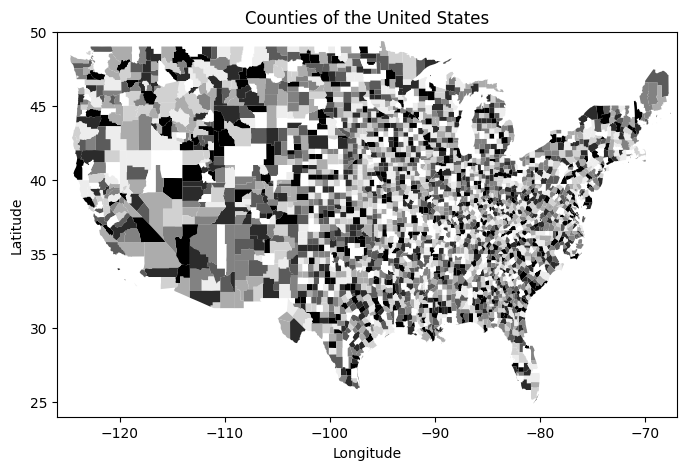

In [126]:
fig, ax = plt.subplots(figsize=(8, 5))
patches, colors, ncolor = [], [], 8

for n, county in enumerate(counties['features']):
    # Only use first polygon if multiple discontiguous regions
    poly = np.array(county['geometry']['coordinates'][0])
    poly = poly.reshape(-1, 2)
    polygon = Polygon(poly)
    patches.append(polygon)
    colors.append(n % ncolor)

p = PatchCollection(patches, cmap=cm.get_cmap('Greys', ncolor))
p.set_array(np.array(colors))
ax.add_collection(p)

ax.set_ylim(24, 50)
ax.set_ylabel("Latitude")
ax.set_xlim(-126, -67)
ax.set_xlabel("Longitude")
ax.set_title("Counties of the United States");
plt.savefig("img/(Ch02)Counties of the United States.png")

### Tidy Geography

In [127]:
fips = pd.read_csv('data/FIPS.tsv', sep='\t')
fips

,Name,Postal Code,FIPS
0,Alabama,AL,1
1,Alaska,AK,2
2,Arizona,AZ,4
3,Arkansas,AR,5
...,...,...,...
51,Guam,GU,66
52,Northern Mariana Islands,MP,69
53,Puerto Rico,PR,72
54,Virgin Islands,VI,78


In [128]:
fips_map = fips.set_index('FIPS').Name
fips_map

FIPS
1                      Alabama
2                       Alaska
4                      Arizona
5                     Arkansas
                ...           
66                        Guam
69    Northern Mariana Islands
72                 Puerto Rico
78              Virgin Islands
Name: Name, Length: 55, dtype: object

In [129]:
def extremes(coords):
    lat, lon = [], []
    # Expect a list of lists of lists
    for region in coords:
        for point in region:
            lat.append(point[1])
            lon.append(point[0])
    # We are assuming western hemisphere here
    north = max(lat)
    south = min(lat)
    east = max(lon)
    west = min(lon)
    return north, south, east, west

In [130]:
def county_summary(features):
    geo_id = []
    state, county_name, area = [], [], []
    north, south, east, west = [], [], [], []

    for county in features:
        props = county['properties']
        polys = county['geometry']['coordinates']
        geo_id.append(props['GEO_ID'])
        # District of Columbia not US state (default to None)
        state_name = fips_map.get(int(props['STATE']), None)
        state.append(state_name)
        county_name.append(props['NAME'])
        area.append(props['CENSUSAREA'] * 2.59)
        n, s, e, w = extremes(polys)
        north.append(n)
        south.append(s)
        east.append(e)
        west.append(w)

    df = pd.DataFrame({
            'geo_id': geo_id,
            'state': state,
            'county': county_name,
            'area': area,
            'northmost': north,
            'southmost': south,
            'eastmost': east,
            'westmost': west
        })
    return df.set_index('geo_id')

In [131]:
def test_counties(df):
    assert (df.northmost > df.southmost).all()
    assert (df.westmost < df.eastmost).all()
    assert (df.area > 0).all()

In [132]:
census_counties = county_summary(counties['features'])

# Sanity checks (if no assertion violated, we are happy)
test_counties(census_counties)
census_counties

,state,county,area,northmost,southmost,eastmost,westmost
geo_id,,,,,,,
0500000US01001,Alabama,Autauga,1539.58924,32.707386,32.340803,-86.411172,-86.917595
0500000US01009,Alabama,Blount,1669.96984,34.259317,33.765316,-86.303516,-86.963358
0500000US01017,Alabama,Chambers,1545.01529,33.108077,32.72853,-85.123421,-85.593177
0500000US01021,Alabama,Chilton,1794.49186,33.071861,32.661732,-86.374974,-87.019157
...,...,...,...,...,...,...,...
0500000US51021,Virginia,Bland,926.50775,37.293465,36.952417,-80.854627,-81.462213
0500000US51027,Virginia,Buchanan,1302.15617,37.537798,37.041691,-81.738378,-82.305874
0500000US51037,Virginia,Charlotte,1230.95189,37.248759,36.697909,-78.443319,-78.904587
0500000US51041,Virginia,Chesterfield,1096.33923,37.562631,37.22271,-77.244167,-77.855148


### JSON Schema

In [133]:
response = requests.get('https://geojson.org/schema/GeoJSON.json')
geojson_schema = json.loads(response.text)

if msg := not_valid(counties, geojson_schema):
    print(msg)
else:
    print("Everything is Happy!")

Everything is Happy!


In [134]:
user_schema = json.loads("""
{
  "$schema": "http://json-schema.org/draft-07/schema#",
  "$id": "http://kdm.training/user-schema.json",
  "title": "User",
  "description": "A User of Our Computer System",
  "type" : "object",
  "required": ["name", "password"],
  "properties" : {
     "name" : {"type" : "string"},
     "password": {
         "description": "Use special characters and mixed case",
         "type": "string"},
     "lucky_numbers": {
         "description": "Up to 6 favorite numbers 1-100",
         "type": "array",
         "items": {
           "type": "number",
           "minimum": 1,
           "maximum": 100
         },
         "uniqueItems": true,
         "minItems": 0,
         "maxItems": 6
    }
  }
}
""")

In [135]:
david = json.loads("""
{
  "name": "David Mertz",
  "password": "badpassword",
  "details": {
    "profession": "Data Scientist",
    "employer": "KDM"
  },
  "lucky_numbers": [12, 42, 55, 87]
}
""")

if msg := not_valid(david, user_schema):
    print(msg)

In [136]:
barbara_feldon = json.loads("""
{
  "name": 99, 
  "password": "1ibydieZ!S@8"
}
""")

if msg := not_valid(barbara_feldon, user_schema):
    print(msg)

99 is not of type 'string'

Failed validating 'type' in schema['properties']['name']:
    {'type': 'string'}

On instance['name']:
    99


In [137]:
intruder = json.loads("""
{
  "password": "P4cC!^*8chWz8", 
  "profession": "Hacker"
}
""")

if msg := not_valid(intruder, user_schema):
    print(msg)

'name' is a required property

Failed validating 'required' in schema:
    {'$id': 'http://kdm.training/user-schema.json',
     '$schema': 'http://json-schema.org/draft-07/schema#',
     'description': 'A User of Our Computer System',
     'properties': {'lucky_numbers': {'description': 'Up to 6 favorite '
                                                     'numbers 1-100',
                                      'items': {'maximum': 100,
                                                'minimum': 1,
                                                'type': 'number'},
                                      'maxItems': 6,
                                      'minItems': 0,
                                      'type': 'array',
                                      'uniqueItems': True},
                    'name': {'type': 'string'},
                    'password': {'description': 'Use special characters '
                                                'and mixed case',
                    

In [138]:
the_count = json.loads("""
{
  "name": "Count von Count",
  "password": "fourbananas",
  "lucky_numbers": ["one", "two", "three"]
}
""")

if msg := not_valid(the_count, user_schema):
    print(msg, "\n--------------------")

'one' is not of type 'number'

Failed validating 'type' in schema['properties']['lucky_numbers']['items']:
    {'maximum': 100, 'minimum': 1, 'type': 'number'}

On instance['lucky_numbers'][0]:
    'one' 
--------------------


In [139]:
george = json.loads("""
{
  "name": "Georg Cantor",
  "password": "omega_aleph",
  "lucky_numbers": [1, 2, 3, 4, 5, 6, 7, 8]
}
""")

if msg := not_valid(george, user_schema):
    print(msg)

[1, 2, 3, 4, 5, 6, 7, 8] is too long

Failed validating 'maxItems' in schema['properties']['lucky_numbers']:
    {'description': 'Up to 6 favorite numbers 1-100',
     'items': {'maximum': 100, 'minimum': 1, 'type': 'number'},
     'maxItems': 6,
     'minItems': 0,
     'type': 'array',
     'uniqueItems': True}

On instance['lucky_numbers']:
    [1, 2, 3, 4, 5, 6, 7, 8]


In [141]:
revolution_9 = json.loads("""
{
  "name": "Yoko Ono",
  "password": "grapefruit",
  "lucky_numbers": [9, 109, 209]
}
""")

if msg := not_valid(revolution_9, user_schema):
    print(msg)

109 is greater than the maximum of 100

Failed validating 'maximum' in schema['properties']['lucky_numbers']['items']:
    {'maximum': 100, 'minimum': 1, 'type': 'number'}

On instance['lucky_numbers'][1]:
    109


## XML

### User Records

In [142]:
import xml.etree.ElementTree as ET
tree = ET.parse('data/users.xml')

# Let us first find the attributes and text of a profession
prof = tree.find('user').find('details').find('profession')
print("Body (title):", prof.text.strip())
print("Attributes:  ", prof.attrib)

Body (title): Data Scientist
Attributes:   {'employer': 'KDM', 'duration': '26', 'units': 'months'}


In [143]:
items = tree.find('user').find('lucky-numbers').findall('item')
lucky_numbers = [int(item.text) for item in items]
lucky_numbers

[12, 42, 55, 87]

### Keyhole Markup Language

In [144]:
ns = {'kml': "http://www.opengis.net/kml/2.2"}
document = ET.parse('data/gz_2010_us_050_00_20m.kml')

root = document.getroot()
kml_doc = root.find('kml:Document', ns)
folder = kml_doc.find('kml:Folder', ns)

# Make sure we have the same number of counties as with GeoJSON
placemarks = folder.findall('kml:Placemark', ns)
print("Count of placemarks:", len(placemarks))
# Show one Placemark element object
placemarks[0]

Count of placemarks: 3221


<Element '{http://www.opengis.net/kml/2.2}Placemark' at 0xfffeed58b380>

In [145]:
# The name of the county is comparatively straightforward
print("County name:", placemarks[0].find('kml:name', ns).text)

# Other county info is only distinguished by attribute
sdata = (placemarks[0].find('kml:ExtendedData', ns)
                      .find('kml:SchemaData', ns)
                      .findall('kml:SimpleData', ns))

# We are going to want GEO_ID, STATE and CENSUSAREA
for record in sdata:
    print(record.attrib, record.text)

County name: Autauga
{'name': 'Name'} Autauga
{'name': 'GEO_ID'} 0500000US01001
{'name': 'STATE'} 01
{'name': 'COUNTY'} 001
{'name': 'LSAD'} County
{'name': 'CENSUSAREA'} 594.436000000000035


In [146]:
coords = (placemarks[0].find('kml:Polygon', ns)
                       .find('kml:outerBoundaryIs', ns)
                       .find('kml:LinearRing', ns)
                       .find('kml:coordinates', ns))
pprint(coords.text)

('-86.497916734108713,32.346347937379285,123.940341341309249 '
 '-86.719045580223096,32.404719907202413,124.507383406162262 '
 '-86.816062031841554,32.342711234558017,124.433184524998069 '
 '-86.891734835750142,32.50487314981855,125.151479452848434 '
 '-86.918751525796665,32.666059588245083,125.785741473548114 '
 '-86.714541775531544,32.66362459160964,125.451970156282187 '
 '-86.715371359148733,32.707584324141543,125.614226697944105 '
 '-86.414261392701192,32.709278995622782,125.144079957157373 '
 '-86.41231357529395,32.411845326016262,124.046804890967906 '
 '-86.497916734108713,32.346347937379285,123.940341341309249')


In [147]:
def kml_extremes(coordinates):
    "Pass in a KML coordinates ElementTree object"
    text_points = coordinates.text.split()
    points = [p.split(',') for p in text_points]
    points = [[float(p[0]), float(p[1])] for p in points]
    # We pass a list-of-list-of-lists here
    return extremes([points])

kml_extremes(coords)

(32.70927899562278, 32.34271123455802, -86.41231357529395, -86.91875152579667)

In [148]:
def kml_county_summary(placemarks, ns=ns):
    geo_id = []
    state, county_name, area = [], [], []
    north, south, east, west = [], [], [], []

    for placemark in placemarks:
        # Get county name here and below to assure consistency
        name = placemark.find('kml:name', ns).text
        
        # Other county info is distinguished by XML attribute
        sdata = (placemark.find('kml:ExtendedData', ns)
                          .find('kml:SchemaData', ns)
                          .findall('kml:SimpleData', ns))
        # We want Name, GEO_ID, STATE and CENSUSAREA
        for record in sdata:
            rectype = record.attrib['name']  # XML attrib
            if rectype == 'Name':  # String 'Name' (county)
                # If name is recorded differently, problem!
                assert record.text == name
                county_name.append(name)
            elif rectype == 'GEO_ID':
                geo_id.append(record.text)
            elif rectype == 'CENSUSAREA':
                # Convert to km^2 from mi^2
                area.append(float(record.text) * 2.59)
            elif rectype == 'STATE':
                # District of Columbia is not a US state
                state_name = fips_map.get(int(record.text), None)
                state.append(state_name)

        # We are going to "cheat" here a little bit.  
        # Sometimes a placemark has a top level <MultiGeometry>
        # with several Polygons; we will skip that calculation 
        try:
            coordinates = (placemark
                    .find('kml:Polygon', ns)
                    .find('kml:outerBoundaryIs', ns)
                    .find('kml:LinearRing', ns)
                    .find('kml:coordinates', ns))                
            n, s, e, w = kml_extremes(coordinates)
        except AttributeError:
            n, s, e, w = None, None, None, None
            
        north.append(n); south.append(s); 
        east.append(e); west.append(w)

    df = pd.DataFrame({
            'geo_id': geo_id, 'state': state, 
            'county': county_name, 'area': area,
            'northmost': north, 'southmost': south,
            'eastmost': east, 'westmost': west
        })
    return df.set_index('geo_id')

In [149]:
kml_counties = kml_county_summary(placemarks)
kml_counties

,state,county,area,northmost,southmost,eastmost,westmost
geo_id,,,,,,,
0500000US01001,Alabama,Autauga,1539.58924,32.709279,32.342711,-86.412314,-86.918752
0500000US01009,Alabama,Blount,1669.96984,34.261131,33.767154,-86.304677,-86.964531
0500000US01017,Alabama,Chambers,1545.01529,33.109960,32.730429,-85.124537,-85.594308
0500000US01021,Alabama,Chilton,1794.49186,33.073731,32.663625,-86.376119,-87.020318
...,...,...,...,...,...,...,...
0500000US51021,Virginia,Bland,926.50775,37.295189,36.954152,-80.855694,-81.463294
0500000US51027,Virginia,Buchanan,1302.15617,37.539502,37.043415,-81.739470,-82.306981
0500000US51037,Virginia,Charlotte,1230.95189,37.250505,36.699679,-78.444320,-78.905600
0500000US51041,Virginia,Chesterfield,1096.33923,37.564372,37.224467,-77.245139,-77.856138


## Configuration Files

### INI and Flat Custom Formats

In [ ]:
import configparser
cfg = configparser.ConfigParser()
cfg.read('data/example.ini')

print("Sections:   ", cfg.sections())
print("Owner keys: ", [k for k in cfg['owner']])
print("Owner/name: ", cfg['owner']['name'])
print("Port #:     ", cfg['database'].getint('port'))

### TOML

In [ ]:
!pip install toml

In [ ]:
import toml
toml.load(open('data/example.toml'))

In [ ]:
with open('data/example-bad.toml') as fh:
    try:
        cfg = toml.load(fh)
    except Exception as err:
        print_err(err)

In [ ]:
!cat -n data/example-bad.toml | tail -8

In [ ]:
%%R
library(RcppTOML)
parseTOML("data/example.toml")

### Yet Another Markup Language

In [ ]:
import yaml
order = yaml.load(open('data/example.yaml'), Loader=yaml.Loader)
order

In [ ]:
# Is nested dict same object under different keys?
order['ship-to'] is order['bill-to']

In [ ]:
with open('data/multidoc.yaml') as stream:
    docs = yaml.load_all(stream, Loader=yaml.Loader)
    print(docs, '\n')
    for doc in docs:
        print(doc)

In [ ]:
try:
    yaml.load(open('data/example-bad.yaml'), Loader=yaml.Loader)
except Exception as err:
    print_err(err)

In [ ]:
%%bash
cat -n data/example-bad.yaml | sed '15,19p;d' 

In [ ]:
try:
    for doc in yaml.load_all(open('data/multidoc-bad.yaml'), Loader=yaml.Loader):
        print(doc)
except Exception as err:
    print_err(err)

## NoSQL Databases

For more details about PyMongo, please read its [documentation](https://www.mongodb.com/docs/languages/python/pymongo-driver/current/).

In [5]:
# Assume that MongoDB is running on local system
from pymongo import MongoClient
client = MongoClient('mongodb://localhost:27017')

In [6]:
# What databases exist on the local server?
client.list_database_names()

['admin', 'config', 'local']

In [7]:
# Make the "business" database
make_mongo_biz(client)
make_dbm_biz(client)

Created 50 restaurants; 5000 reviews


In [8]:
db_biz = client.business
print("Restaurants:", db_biz.info.count_documents({}))
for biz in db_biz.info.find(limit=3):
    pprint(biz)

Restaurants: 50
{'_id': ObjectId('68cc50805be7d12e24edf531'),
 'cuisine': 'Mexican',
 'name': 'Kitchen Tasty Inc.',
 'phone': '+1 524 555 9265'}
{'_id': ObjectId('68cc50805be7d12e24edf532'),
 'cuisine': 'Sandwich',
 'name': 'Sweet Delight Take-Out',
 'phone': '+1 784 555 6824'}
{'_id': ObjectId('68cc50805be7d12e24edf533'),
 'cuisine': 'Vegetarian',
 'name': 'City City Inc.',
 'phone': '+1 259 555 8923'}


In [9]:
print("Reviews:", db_biz.reviews.count_documents({}))
for review in db_biz.reviews.find(limit=3):
    pprint(review)

Reviews: 5000
{'_id': ObjectId('68cc50805be7d12e24edf563'),
 'name': 'Goat Salty Take-Out',
 'price': 'expensive',
 'rating': 5}
{'_id': ObjectId('68cc50805be7d12e24edf564'),
 'name': 'Big City Restaurant',
 'price': 'expensive',
 'rating': 2}
{'_id': ObjectId('68cc50805be7d12e24edf565'),
 'name': 'Sweet Tasty Take-Out',
 'price': 'reasonable',
 'rating': 1}


In [10]:
# since the restaurants were created at random, let's list the
# names of the restaurants with cheap prices
results = db_biz.reviews.distinct('name', {
    'price': 'cheap'
})
for restaurant in results:
    print(restaurant)

Big Big Take-Out
Big City Restaurant
Big Delight Restaurant
Big Fish Restaurant
Big Goat Inc.
Big Kitchen Restaurant
Big Kitchen Take-Out
Big Sweet Take-Out
Big Tasty Take-Out
City Big Inc.
City Big Take-Out
City City Inc.
City Delight Restaurant
City Kitchen Restaurant
Delight Big Restaurant
Delight Fish Restaurant
Delight Kitchen Inc.
Delight Salty Inc.
Delight Sweet Take-Out
Fish Big Inc.
Fish Big Restaurant
Goat Fish Take-Out
Goat Salty Inc.
Goat Salty Take-Out
Goat Sweet Inc.
Goat Sweet Restaurant
Goat Tasty Inc.
Goat Tasty Restaurant
Kitchen Fish Restaurant
Kitchen Tasty Inc.
Salty Big Inc.
Salty City Restaurant
Salty Kitchen Restaurant
Salty Kitchen Take-Out
Salty Salty Restaurant
Salty Sweet Take-Out
Sweet City Inc.
Sweet Delight Take-Out
Sweet Kitchen Inc.
Sweet Tasty Inc.
Sweet Tasty Restaurant
Sweet Tasty Take-Out
Tasty City Take-Out
Tasty Delight Inc.
Tasty Fish Inc.
Tasty Kitchen Restaurant
Tasty Sweet Take-Out
Tasty Tasty Restaurant


In [11]:
query = {'price': 'cheap', 'name': 'City City Inc.'}
for review in db_biz.reviews.find(query, limit=4):
    pprint(review)

{'_id': ObjectId('68cc50805be7d12e24edf643'),
 'name': 'City City Inc.',
 'price': 'cheap',
 'rating': 3}
{'_id': ObjectId('68cc50805be7d12e24edf649'),
 'name': 'City City Inc.',
 'price': 'cheap',
 'rating': 7}
{'_id': ObjectId('68cc50805be7d12e24edf782'),
 'name': 'City City Inc.',
 'price': 'cheap',
 'rating': 7}
{'_id': ObjectId('68cc50805be7d12e24edf84c'),
 'name': 'City City Inc.',
 'price': 'cheap',
 'rating': 4}


#### Missing Fields

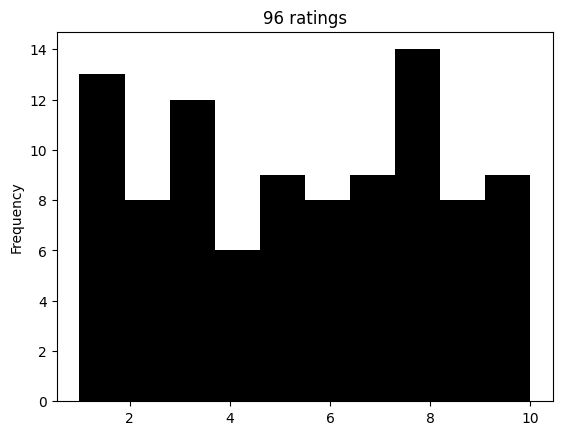

In [12]:
ratings = []
query = {'name': 'City City Inc.'}
for review in db_biz.reviews.find(query):
    try:
        ratings.append(review['rating'])
    except KeyError:
        pass

n = len(ratings)
pd.Series(ratings).plot(kind="hist", title=f"{n} ratings")
plt.savefig(f"img/(Ch02){n} ratings.png")

In [13]:
db_biz.reviews.count_documents({'name': 'City City Inc.'})

98

In [14]:
list(db_biz.reviews.find({'name': 'City City Inc.', 'rating': None}))

[{'_id': ObjectId('68cc50805be7d12e24edffea'),
  'name': 'City City Inc.',
  'price': 'expensive'},
 {'_id': ObjectId('68cc50805be7d12e24ee02a6'),
  'name': 'City City Inc.',
  'price': 'cheap'}]

#### Denormalization and Its Discontents

In [15]:
def has_best_review(name, db=db_biz):
    "Return phone if restaurant has at least one 10 rating"
    query = {'name': name, 'rating': 10}
    review = None
    
    # Fast path has phone in local results
    for review in db.reviews.find(query):
        phone = review.get('phone')
        if phone:
            return f"Call {name} at {phone}! (FAST query)"

    # If there were no ratings of 10, we don't like it!
    if not review:
        return f"Do not bother with {name}!"

    # MUCH SLOWER path is second query
    info = db.info.find_one({'name': name})
    return f"Call {name} at {info['phone']}! (SLOW query)"

In [16]:
# since the restaurants were created at random, let's list the
# names of the restaurants with at least a rating of 10
results = db_biz.reviews.distinct('name', {
    'rating': 10
})
for restaurant in results:
    print(restaurant)

Big Big Take-Out
Big City Restaurant
Big Delight Restaurant
Big Fish Restaurant
Big Goat Inc.
Big Kitchen Restaurant
Big Kitchen Take-Out
Big Sweet Take-Out
Big Tasty Take-Out
City Big Inc.
City Big Take-Out
City City Inc.
City Delight Restaurant
City Kitchen Restaurant
Delight Big Restaurant
Delight Fish Restaurant
Delight Kitchen Inc.
Delight Salty Inc.
Delight Sweet Take-Out
Fish Big Inc.
Fish Big Restaurant
Goat Fish Take-Out
Goat Salty Inc.
Goat Salty Take-Out
Goat Sweet Inc.
Goat Sweet Restaurant
Goat Tasty Inc.
Goat Tasty Restaurant
Kitchen Fish Restaurant
Kitchen Tasty Inc.
Salty Big Inc.
Salty City Restaurant
Salty Kitchen Restaurant
Salty Kitchen Take-Out
Salty Salty Restaurant
Salty Sweet Take-Out
Sweet City Inc.
Sweet Delight Take-Out
Sweet Kitchen Inc.
Sweet Tasty Inc.
Sweet Tasty Restaurant
Sweet Tasty Take-Out
Tasty City Take-Out
Tasty Delight Inc.
Tasty Fish Inc.
Tasty Kitchen Restaurant
Tasty Sweet Take-Out
Tasty Tasty Restaurant


In [17]:
has_best_review('Sweet Tasty Restaurant')

'Call Sweet Tasty Restaurant at +1 497 555 2810! (FAST query)'

In [18]:
has_best_review('Delight Big Restaurant')

'Call Delight Big Restaurant at +1 160 555 9643! (SLOW query)'

In [19]:
has_best_review('Out of Business')

'Do not bother with Out of Business!'

In [20]:
query = {'name': 'Sweet Tasty Restaurant', 
         'rating': 10, 'phone':{"$ne":None}}

db_biz.reviews.find_one(query)

{'_id': ObjectId('68cc50805be7d12e24edff2a'),
 'name': 'Sweet Tasty Restaurant',
 'price': 'expensive',
 'rating': 10,
 'phone': '+1 497 555 2810'}

In [21]:
db_biz.info.find_one({'name': 'Sweet Tasty Restaurant'})

{'_id': ObjectId('68cc50805be7d12e24edf560'),
 'name': 'Sweet Tasty Restaurant',
 'cuisine': 'American',
 'phone': '+1 497 555 2810'}

### Key/Value Stores

In [22]:
biz = dbm.open('data/keyval.db')
seed(6)
# Keys are bytes; could convert to strings if desired
sample(list(biz.keys()), 10)

[b'Big City Restaurant::info::phone',
 b'Delight Kitchen Inc.::ratings',
 b'Delight Salty Inc.::info::phone',
 b'Goat Sweet Inc.//ratings',
 b'Sweet City Inc.::ratings',
 b'DESCRIPTION',
 b'Sweet Kitchen Inc.::ratings',
 b'Big Goat Inc.::info::cuisine',
 b'Delight Big Restaurant::info::phone',
 b'Goat Salty Take-Out::info::phone']

In [23]:
name = b"Big Goat Inc."
print("Overview:", biz[b"DESCRIPTION"])
print("Cuisine: ", biz[name + b"::info::cuisine"] )
print("Ratings: ", biz[name + b"::ratings"][:30], "...")

Overview: b'Restaurant information'
Cuisine:  b'Pizza'
Ratings:  b'9;9;2;8;8;8;3;1;8;6;4;2;1;4;6;' ...


In [24]:
for key, val in biz.items():
    if key.startswith(b'Big Goat Inc.::'):
        print(key.decode(), '\t', val[:30].decode())

Big Goat Inc.::ratings 	 9;9;2;8;8;8;3;1;8;6;4;2;1;4;6;
Big Goat Inc.::info::phone 	 +1 456 555 6549
Big Goat Inc.::info::cuisine 	 Pizza


In [25]:
for key, val in biz.items():
    if key.startswith(b'Goat Sweet Inc.'):
        print(key, val[:30])

b'Goat Sweet Inc.::ratings' b'10;4;7;2;10;10;7;3;3;2;1;2;10;'
b'Goat Sweet Inc.//ratings' b'10;6'
b'Goat Sweet Inc.::info::phone' b'+1 746 555 5897'
b'Goat Sweet Inc.::info::cuisine' b'Sushi'


## Exercises

### Create a Relational Model

In [ ]:
dbm.whichdb('data/keyval.db')